# RT-DETR-L Training

## Config and Paths

In [1]:
import os

DATASET_YAML = '/home/achin/COS40007-Group/dataset/dataset.yaml'
WEIGHTS_PATH = '/home/achin/COS40007-Group/rtdetr-l.pt'
PROJECT_DIR  = '/home/achin/COS40007-Group/runs/defect_detection'
DATASET_ROOT = '/home/achin/COS40007-Group/dataset'

RUN = 'rtdetr_l_v4'
CLASS_NAMES = ['crack', 'pothole', 'wall_peeling']
BACKGROUND_PREFIXES = ('wall-', 'road-')
NC = 3
SPLITS = ['train', 'val', 'test']

IMAGE_DIRS = {s: os.path.join(DATASET_ROOT, s, 'images') for s in SPLITS}
LABEL_DIRS = {s: os.path.join(DATASET_ROOT, s, 'labels') for s in SPLITS}

print("Paths configured:")
for s in SPLITS:
    all_imgs = [f for f in os.listdir(IMAGE_DIRS[s]) if f.endswith('.jpg')]
    bg_imgs  = [f for f in all_imgs if f.startswith(BACKGROUND_PREFIXES)]
    def_imgs = [f for f in all_imgs if not f.startswith(BACKGROUND_PREFIXES)]
    print(f"  {s}: {len(def_imgs)} defect + {len(bg_imgs)} background = {len(all_imgs)} total")

Paths configured:
  train: 542 defect + 79 background = 621 total
  val: 166 defect + 18 background = 184 total
  test: 163 defect + 18 background = 181 total


## Dataset Exploratory Data Analysis


TRAIN: 621 images
  crack: 237 annotations
  pothole: 363 annotations
  wall_peeling: 278 annotations
  background (empty): 84 images
  bg/defect ratio: 0.10 ✅

VAL: 184 images
  crack: 65 annotations
  pothole: 97 annotations
  wall_peeling: 82 annotations
  background (empty): 18 images
  bg/defect ratio: 0.07 ✅

TEST: 181 images
  crack: 66 annotations
  pothole: 120 annotations
  wall_peeling: 78 annotations
  background (empty): 18 images
  bg/defect ratio: 0.07 ✅


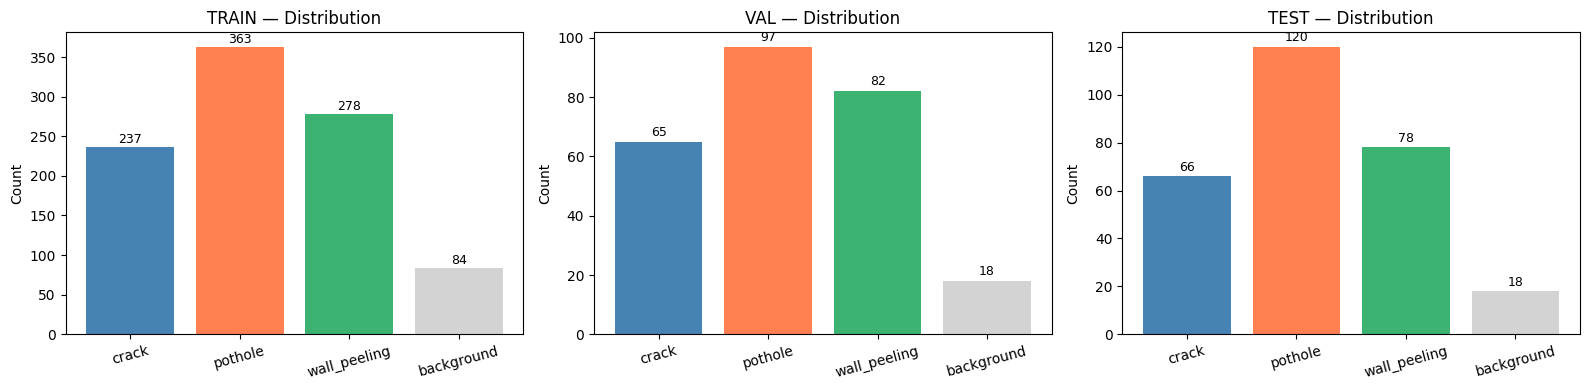

In [2]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def count_labels(split):
    label_dir = Path(LABEL_DIRS[split])
    class_counts = Counter()
    bg_count = 0
    for txt in label_dir.glob('*.txt'):
        content = txt.read_text().strip()
        if not content:
            bg_count += 1
        else:
            for line in content.splitlines():
                if line.strip():
                    cls = int(line.split()[0])
                    class_counts[cls] += 1
    return class_counts, bg_count

for split in SPLITS:
    counts, bg_count = count_labels(split)
    total_images = len(list(Path(IMAGE_DIRS[split]).glob('*.jpg')))
    print(f"\n{split.upper()}: {total_images} images")
    for cls_id in sorted(counts):
        print(f"  {CLASS_NAMES[cls_id]}: {counts[cls_id]} annotations")
    print(f"  background (empty): {bg_count} images")
    ratio = bg_count / max(sum(counts.values()), 1)
    print(f"  bg/defect ratio: {ratio:.2f} {'⚠️ consider reducing' if ratio > 0.5 else '✅'}")

# Bar chart — defect classes only, background shown separately
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split in zip(axes, SPLITS):
    counts, bg_count = count_labels(split)
    names  = [CLASS_NAMES[i] for i in sorted(counts)] + ['background']
    values = [counts[i] for i in sorted(counts)] + [bg_count]
    colors = ['steelblue', 'coral', 'mediumseagreen', 'lightgray']
    bars = ax.bar(names, values, color=colors)
    ax.set_title(f'{split.upper()} — Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

## Visualise Sample Annotations

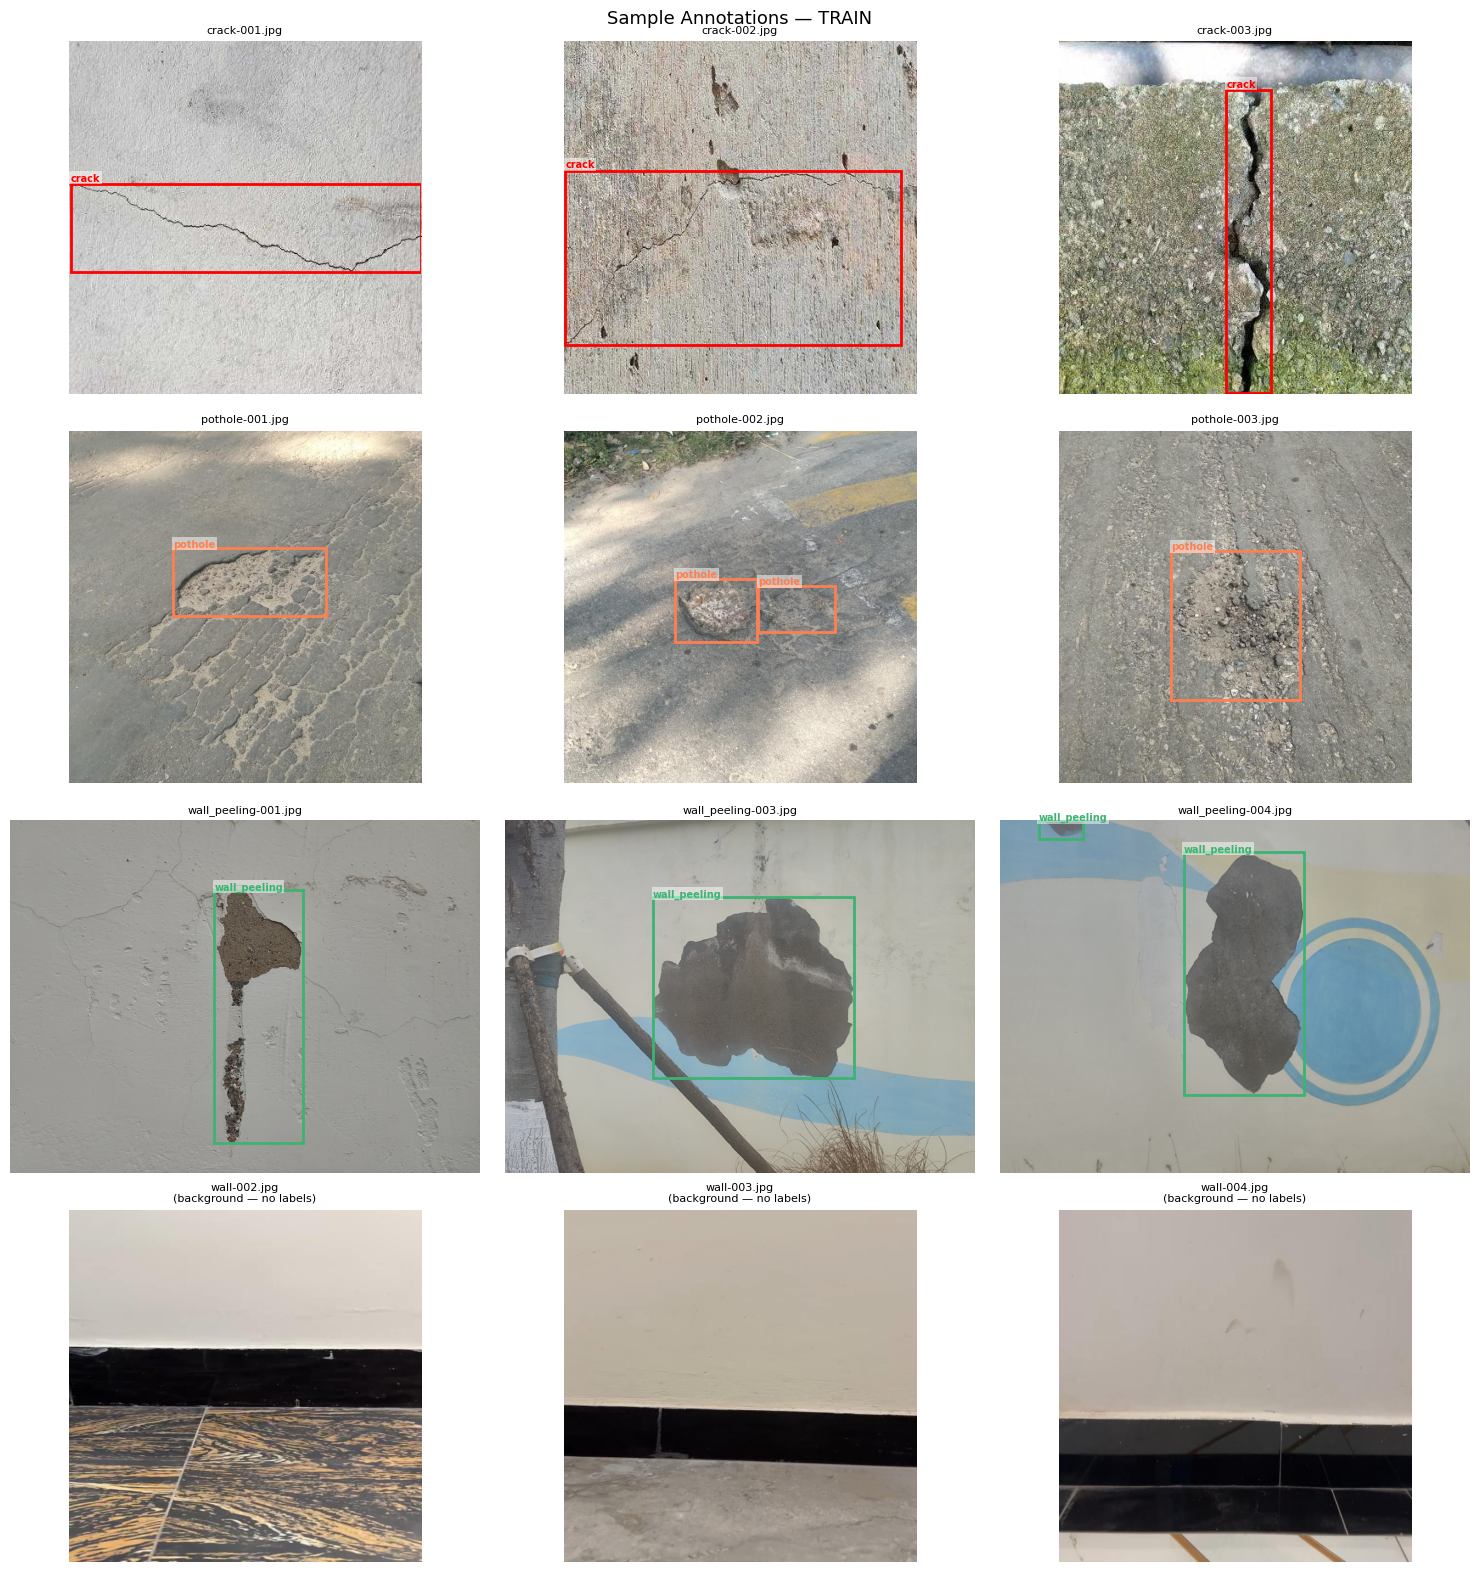

In [3]:
import matplotlib.patches as patches
from PIL import Image

def visualize_samples_by_class(split, n_per_class=3):
    img_dir = Path(IMAGE_DIRS[split])
    lbl_dir = Path(LABEL_DIRS[split])
    COLORS  = ['red', 'coral', 'mediumseagreen']

    # defect rows + 1 background row
    total_rows = NC + 1
    fig, axes = plt.subplots(total_rows, n_per_class, figsize=(5 * n_per_class, 4 * total_rows))

    # --- defect class rows ---
    for row, cls_name in enumerate(CLASS_NAMES):
        cls_imgs = sorted(img_dir.glob(f'{cls_name}-*.jpg'))[:n_per_class]

        for col in range(n_per_class):
            ax = axes[row][col]
            ax.axis('off')

            if col >= len(cls_imgs):
                ax.set_title(f'{cls_name} — no sample', fontsize=9)
                continue

            img_path = cls_imgs[col]
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            ax.imshow(img)
            ax.set_title(f'{img_path.name}', fontsize=8)

            lbl_path = lbl_dir / (img_path.stem + '.txt')
            if lbl_path.exists():
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.split()
                    if not parts:
                        continue
                    c, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h,
                        linewidth=2, edgecolor=COLORS[c % len(COLORS)], facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, CLASS_NAMES[c], color=COLORS[c % len(COLORS)],
                            fontsize=7, fontweight='bold',
                            bbox=dict(facecolor='white', alpha=0.5, pad=1, edgecolor='none'))

    bg_imgs = []
    for prefix in BACKGROUND_PREFIXES:
        bg_imgs.extend(sorted(img_dir.glob(f'{prefix}*.jpg')))
    bg_imgs = bg_imgs[:n_per_class]

    for col in range(n_per_class):
        ax = axes[NC][col]
        ax.axis('off')
        if col < len(bg_imgs):
            img = Image.open(bg_imgs[col]).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{bg_imgs[col].name}\n(background — no labels)', fontsize=8)
        else:
            ax.set_title('background — no sample', fontsize=9)

    plt.suptitle(f'Sample Annotations — {split.upper()}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PROJECT_DIR, f'sample_annotations_{split}.png'), dpi=150)
    plt.show()

visualize_samples_by_class('train', n_per_class=3)

## Training

In [4]:
from pathlib import Path

for split in SPLITS:
    cache = Path(LABEL_DIRS[split]).parent / 'labels.cache'
    if cache.exists():
        cache.unlink()
        print(f"Deleted cache: {cache}")
    else:
        print(f"No cache found for {split} — OK")

Deleted cache: /home/achin/COS40007-Group/dataset/train/labels.cache
Deleted cache: /home/achin/COS40007-Group/dataset/val/labels.cache
Deleted cache: /home/achin/COS40007-Group/dataset/test/labels.cache


In [5]:
from ultralytics import RTDETR

os.makedirs(PROJECT_DIR, exist_ok=True)

model = RTDETR(WEIGHTS_PATH)

results = model.train(
    data=DATASET_YAML,
    epochs=300,
    imgsz=640,
    batch=16,
    lr0=1e-4,
    lrf=0.001,
    warmup_epochs=5,
    warmup_bias_lr=0.1,
    optimizer='AdamW',
    weight_decay=1e-4,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.1,
    scale=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    degrees=10.0,
    translate=0.1,
    workers=16,
    save=True,
    plots=True,
    amp=False,
    device=0,
    project=PROJECT_DIR,
    name=RUN,
    exist_ok=True,
)

print("Training complete.")
print(f"Best weights saved to: {PROJECT_DIR}/{RUN}/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/achin/COS40007-Group/dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/achin/COS40007-Group/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_v4, nbs=64, nms=False, opset=None,

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 35.0±34.8 MB/s, size: 95.5 KB)
val: Scanning /home/achin/COS40007-Group/dataset/val/labels... 184 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 184/184 1.0Kit/s 0.2s3s
val: New cache created: /home/achin/COS40007-Group/dataset/val/labels.cache


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 143 weight(decay=0.0), 206 weight(decay=0.0001), 226 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/labels.jpg... 
Image sizes 640 train, 640 val
Using 16 dataloader workers
Logging results to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4
Starting training for 300 epochs...

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

    153/300      74.1G     0.2421     0.3148    0.09841          2       1280: 100% ━━━━━━━━━━━━ 40/40 1.0s/it 40.8s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.9it/s 1.2s0.3s
                   all        184        244      0.874      0.844      0.849      0.551

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    154/300      74.1G     0.2362     0.3236    0.09369          2       1280: 100% ━━━━━━━━━━━━ 40/40 1.0s/it 41.0s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 5.0it/s 1.2s0.2s
                   all        184        244      0.854      0.839      0.838      0.544

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    155/300      74.1G     0.2236     0.3087    0.09371          2       1280: 100% ━━━━━━━━━━━━ 40/40 1.0s/it 41.0s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.9it/s 1.2s0.3s
                   all        184        244      0.874      0.839      0.837      0.543
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 105, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

155 epochs completed in 1.923 hours.
Optimizer stripped from /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/weights/last.pt, 66.2MB
Optimizer stripped from /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/weights/best.pt, 66.2MB

Validating /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4/weights/best.pt...
Ultralytics 8.4.56 🚀 Python-3.9.2

## Validation on Val Set

In [6]:
best_weights = os.path.join(PROJECT_DIR, RUN, 'weights', 'best.pt')
trained_model = RTDETR(best_weights)

val_metrics = trained_model.val(
    data=DATASET_YAML,
    split='val',
    plots=True,
    save_json=True,
    project=PROJECT_DIR,
    name=f'{RUN}_val',
    exist_ok=True,
)

print("\n--- Val Metrics ---")
print(f"mAP@50:     {val_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {val_metrics.box.map:.4f}")
print(f"Precision:  {val_metrics.box.mp:.4f}")
print(f"Recall:     {val_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {val_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 513.6±321.3 MB/s, size: 55.7 KB)
val: Scanning /home/achin/COS40007-Group/dataset/val/labels.cache... 184 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 184/184 14.0Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.7it/s 3.2s0.2s
                   all        184        244      0.883      0.843      0.876       0.58
                 crack         51         65      0.766        0.6      0.682      0.251
              potholes         57         97       0.92      0.979      0.984      0.765
          wall_peeling         58         82      0.963      0.951      0.963      0.723
Speed: 1.2ms preprocess, 8.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_val/predictions.json...
Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_val

--- Val Metrics ---
mAP@50:     0.8764
mAP@50-95:  0.5799
Precision:  0.8829
Recall:     0.8435

Per-class AP@50:
  crack: 0.6824
  pothole: 0.9835
  wall_peeling: 0.9633


## Evaluation on Test Set

In [7]:
test_metrics = trained_model.val(
    data=DATASET_YAML,
    split='test',
    plots=True,
    project=PROJECT_DIR,
    name=f'{RUN}_test',
    exist_ok=True,
)

print("\n--- Test Metrics ---")
print(f"mAP@50:     {test_metrics.box.map50:.4f}")
print(f"mAP@50-95:  {test_metrics.box.map:.4f}")
print(f"Precision:  {test_metrics.box.mp:.4f}")
print(f"Recall:     {test_metrics.box.mr:.4f}")
print(f"\nPer-class AP@50:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {test_metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 39.0±28.7 MB/s, size: 59.3 KB)
val: Scanning /home/achin/COS40007-Group/dataset/test/labels... 181 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 181/181 915.0it/s 0.2s.3s
val: New cache created: /home/achin/COS40007-Group/dataset/test/labels.cache


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.8it/s 2.5s0.1s
                   all        181        264      0.798      0.863      0.824      0.552
                 crack         53         66       0.62      0.682       0.56      0.185
              potholes         55        120      0.858      0.959      0.974      0.759
          wall_peeling         55         78      0.915      0.949      0.938      0.712
Speed: 2.1ms preprocess, 6.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/achin/COS40007-Group/runs/defect_detection/rtdetr_l_v4_test

--- Test Metrics ---
mAP@50:     0.8240
mAP@50-95:  0.5520
Precision:  0.7978
Recall:     0.8631

Per-class AP@50:
  crack: 0.5599
  pothole: 0.9738
  wall_peeling: 0.9384


## Training Curves

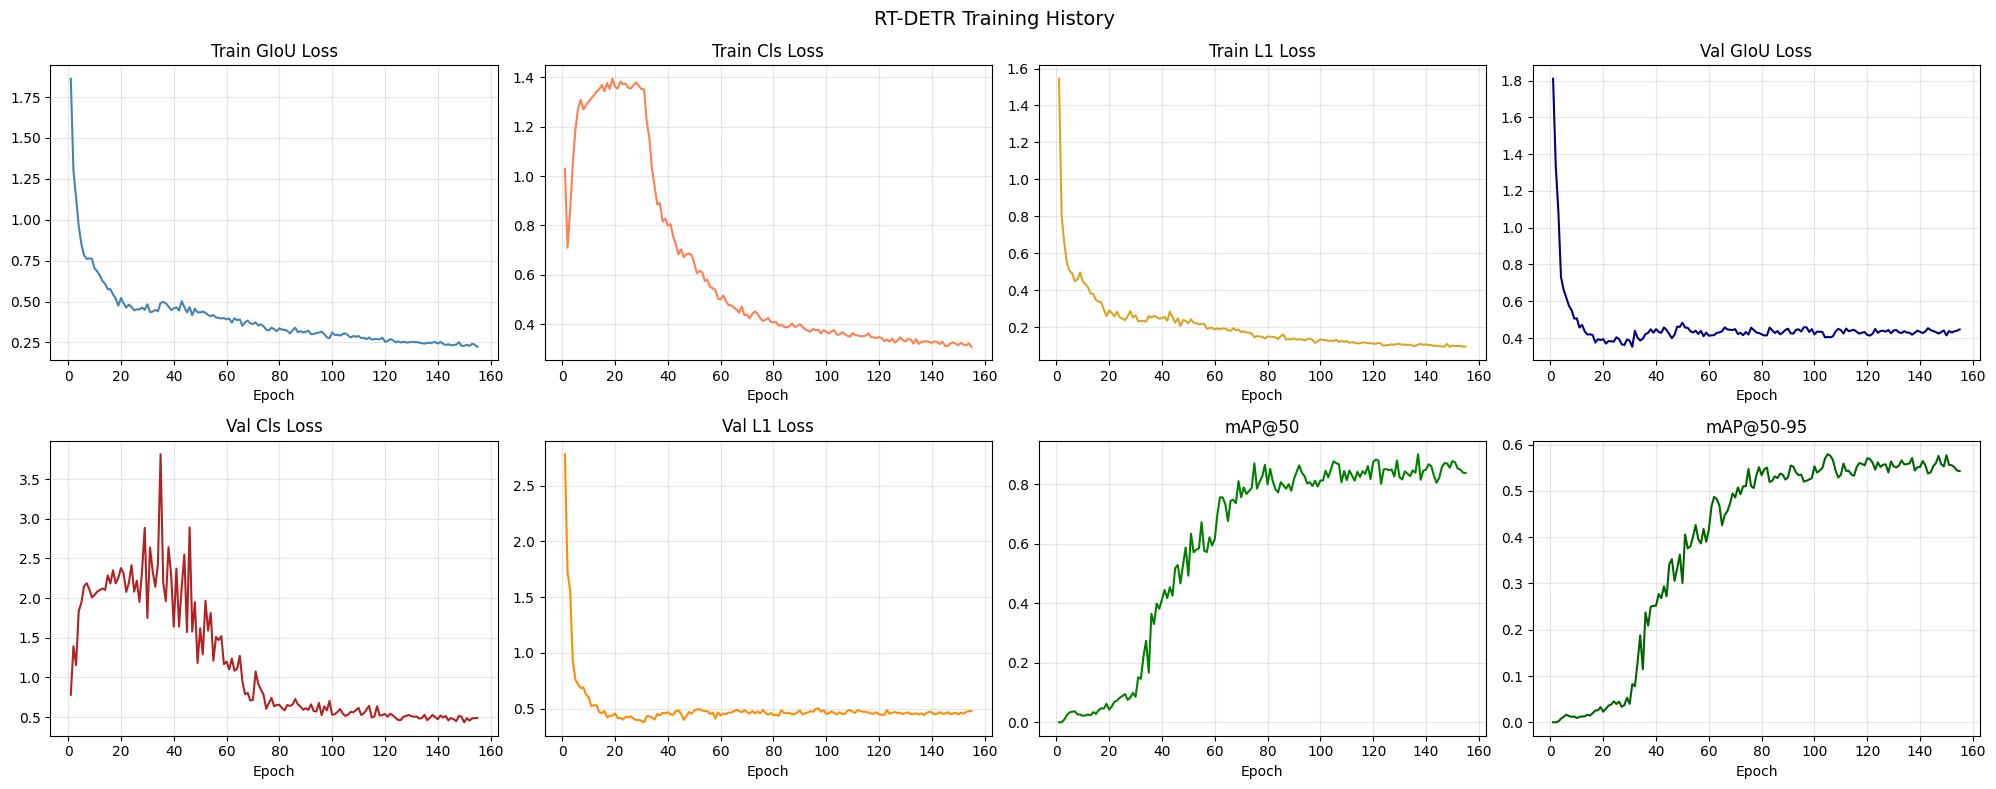

In [8]:
import pandas as pd
import matplotlib.image as mpimg

results_csv = os.path.join(PROJECT_DIR, RUN, 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plots = [
    ('train/giou_loss',       'Train GIoU Loss',  'steelblue'),
    ('train/cls_loss',        'Train Cls Loss',   'coral'),
    ('train/l1_loss',         'Train L1 Loss',    'goldenrod'),
    ('val/giou_loss',         'Val GIoU Loss',    'navy'),
    ('val/cls_loss',          'Val Cls Loss',     'firebrick'),
    ('val/l1_loss',           'Val L1 Loss',      'darkorange'),
    ('metrics/mAP50(B)',      'mAP@50',           'green'),
    ('metrics/mAP50-95(B)',   'mAP@50-95',        'darkgreen'),
    ('metrics/precision(B)',  'Precision',        'purple'),
    ('metrics/recall(B)',     'Recall',           'orange'),
    ('lr/pg0',                'LR (backbone)',    'gray'),
    ('lr/pg1',                'LR (weights)',     'darkgray'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.suptitle('RT-DETR Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Inference and Visualisation on Test Images


image 1/181 /home/achin/COS40007-Group/dataset/test/images/crack-002.jpg: 640x640 5 cracks, 1 potholes, 26.8ms
image 2/181 /home/achin/COS40007-Group/dataset/test/images/crack-008.jpg: 640x640 2 cracks, 38.1ms
image 3/181 /home/achin/COS40007-Group/dataset/test/images/crack-009.jpg: 640x640 2 cracks, 33.5ms
image 4/181 /home/achin/COS40007-Group/dataset/test/images/crack-014.jpg: 640x640 3 cracks, 28.4ms
image 5/181 /home/achin/COS40007-Group/dataset/test/images/crack-016.jpg: 640x640 6 cracks, 29.4ms
image 6/181 /home/achin/COS40007-Group/dataset/test/images/crack-018.jpg: 640x640 1 crack, 27.9ms
image 7/181 /home/achin/COS40007-Group/dataset/test/images/crack-019.jpg: 640x640 1 crack, 1 potholes, 30.3ms
image 8/181 /home/achin/COS40007-Group/dataset/test/images/crack-021.jpg: 640x640 4 cracks, 28.5ms
image 9/181 /home/achin/COS40007-Group/dataset/test/images/crack-027.jpg: 640x640 2 cracks, 1 potholes, 32.0ms
image 10/181 /home/achin/COS40007-Group/dataset/test/images/crack-044.jpg:

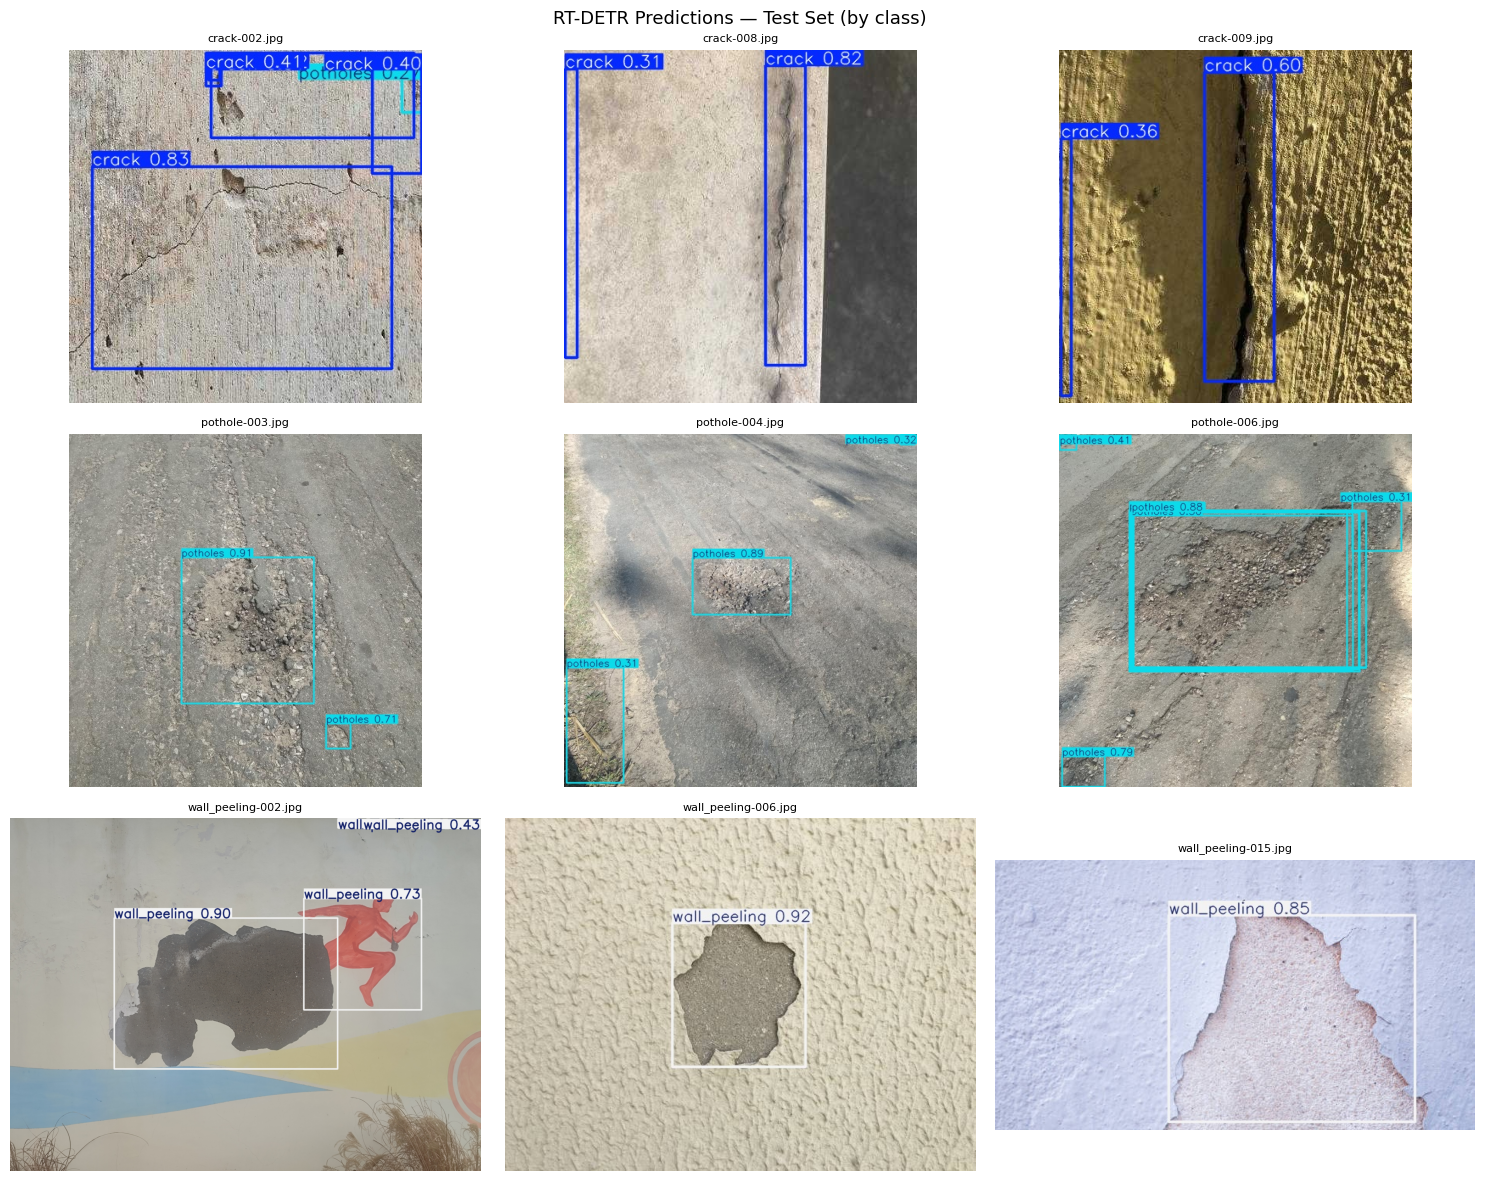

In [9]:
trained_model.predict(
    source=IMAGE_DIRS['test'],
    conf=0.25,
    iou=0.5,
    save=True,
    project=PROJECT_DIR,
    name=f'{RUN}_predictions',
    exist_ok=True,
)

pred_dir = Path(PROJECT_DIR) / f'{RUN}_predictions'

fig, axes = plt.subplots(NC, 3, figsize=(15, 4 * NC))
for row, cls_name in enumerate(CLASS_NAMES):
    cls_preds = sorted(pred_dir.glob(f'{cls_name}-*.jpg'))[:3]
    for col in range(3):
        ax = axes[row][col]
        ax.axis('off')
        if col < len(cls_preds):
            ax.imshow(mpimg.imread(cls_preds[col]))
            ax.set_title(cls_preds[col].name, fontsize=8)
        else:
            ax.set_title(f'{cls_name} — no prediction saved', fontsize=8)

plt.suptitle('RT-DETR Predictions — Test Set (by class)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'prediction_samples.png'), dpi=150)
plt.show()

## Display Evaluation Plots

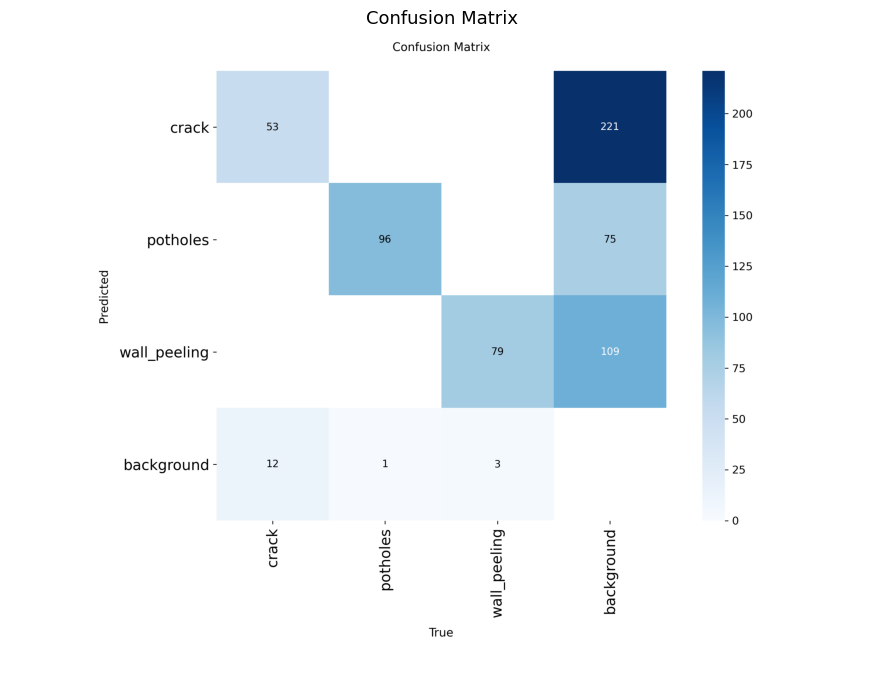

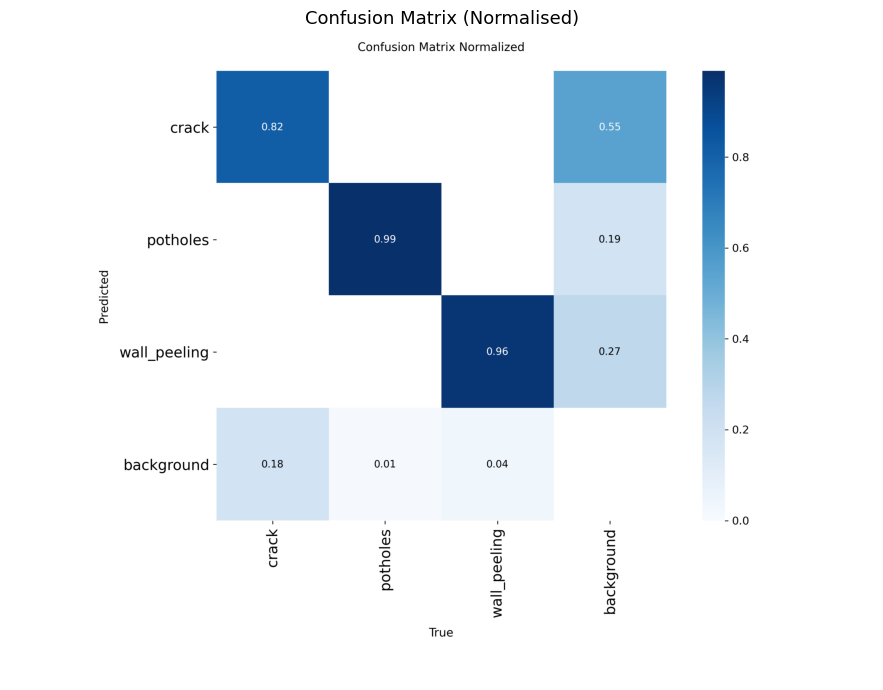

Not yet generated: PR_curve.png
Not yet generated: P_curve.png
Not yet generated: R_curve.png


In [10]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('PR_curve.png',                    'Precision-Recall Curve'),
    ('P_curve.png',                     'Precision Curve'),
    ('R_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")

## Inference Speed Benchmark

In [11]:
import time

test_imgs = list(Path(IMAGE_DIRS['test']).glob('*.jpg'))[:50]

# Warmup
trained_model.predict(source=[str(test_imgs[0])], conf=0.25, verbose=False)

# Timed run
start = time.time()
trained_model.predict(source=[str(p) for p in test_imgs], conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(test_imgs) / elapsed
print(f"Images tested : {len(test_imgs)}")
print(f"Total time    : {elapsed:.2f}s")
print(f"FPS           : {fps:.1f}")
print(f"ms/image      : {1000/fps:.1f}")

Images tested : 50
Total time    : 0.84s
FPS           : 59.2
ms/image      : 16.9


## Display Evaluation Plots

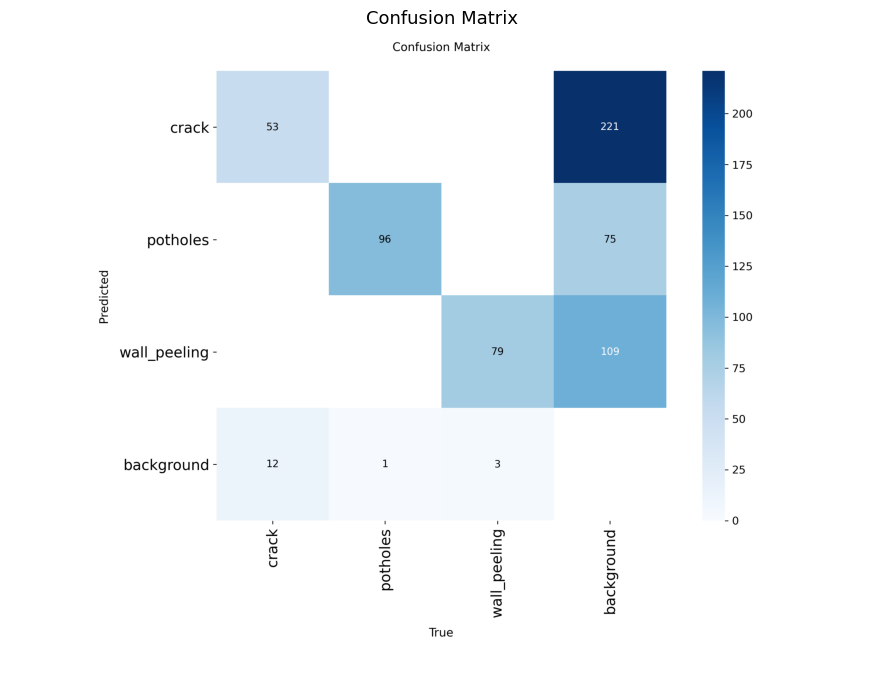

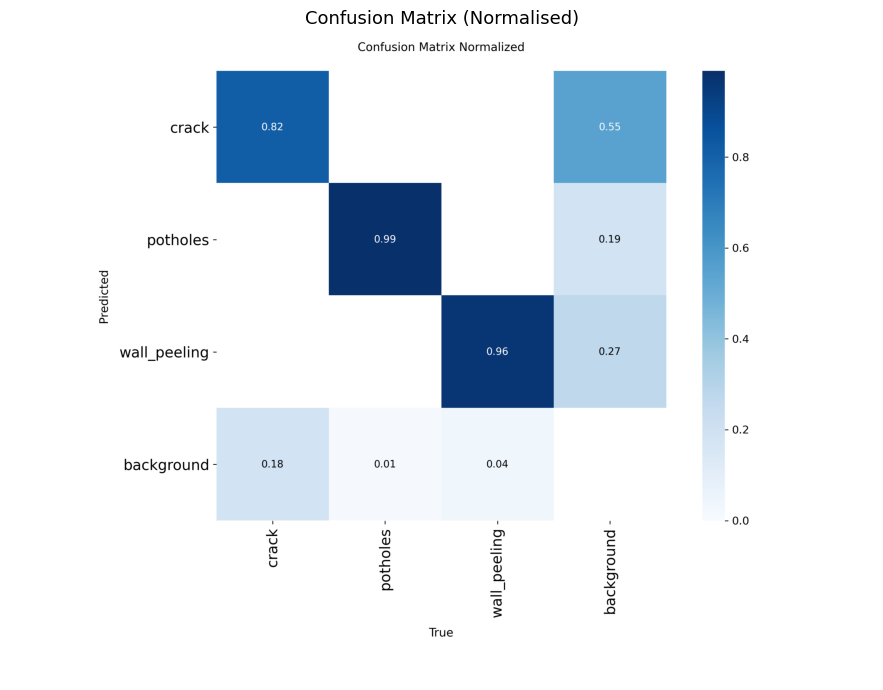

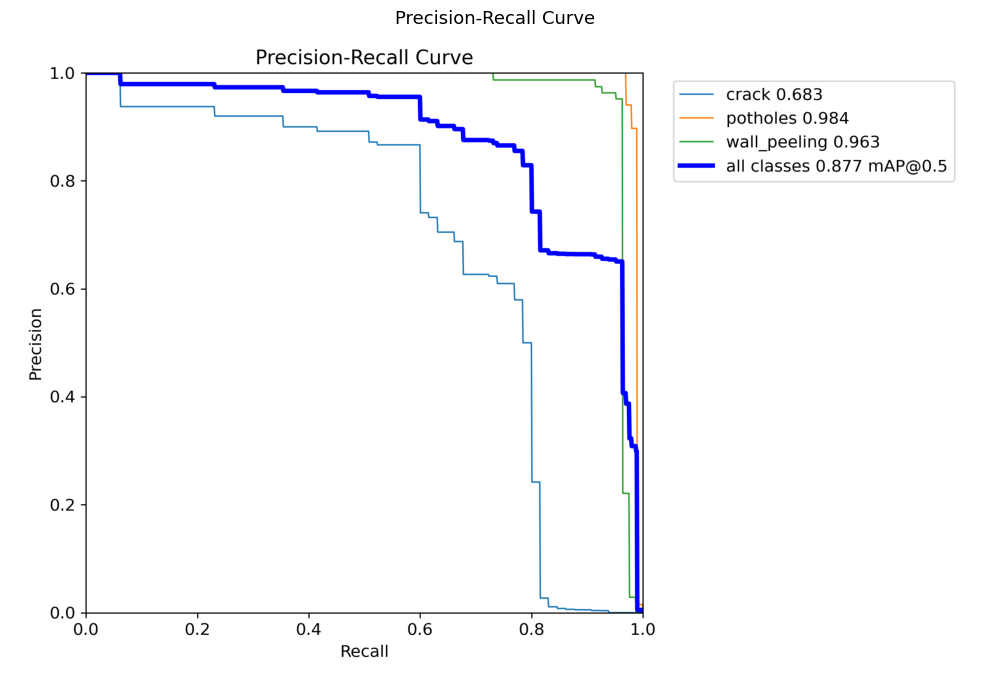

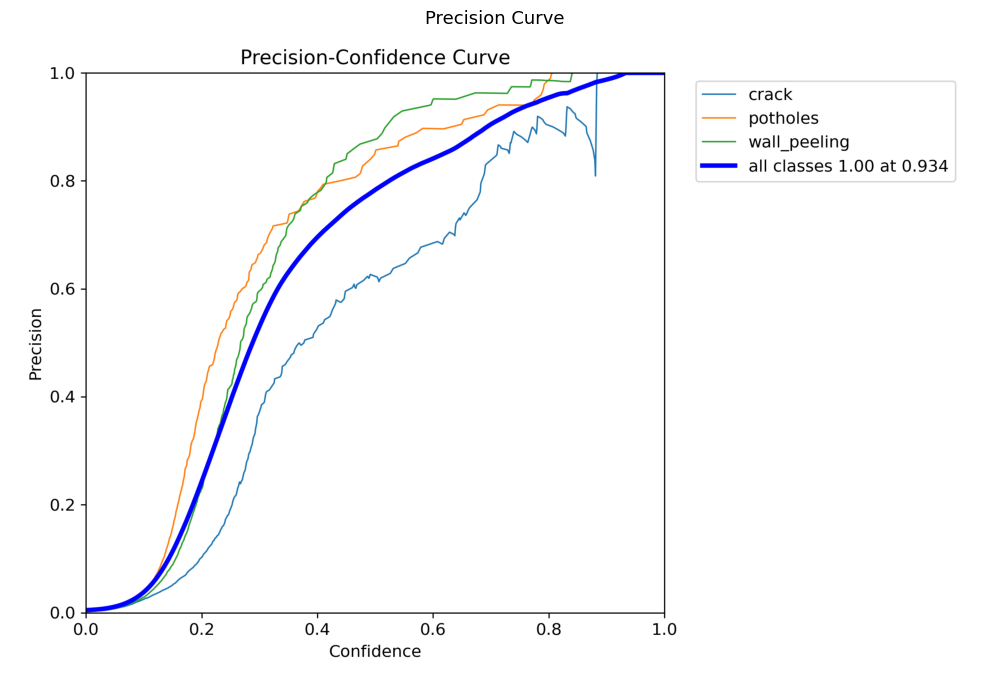

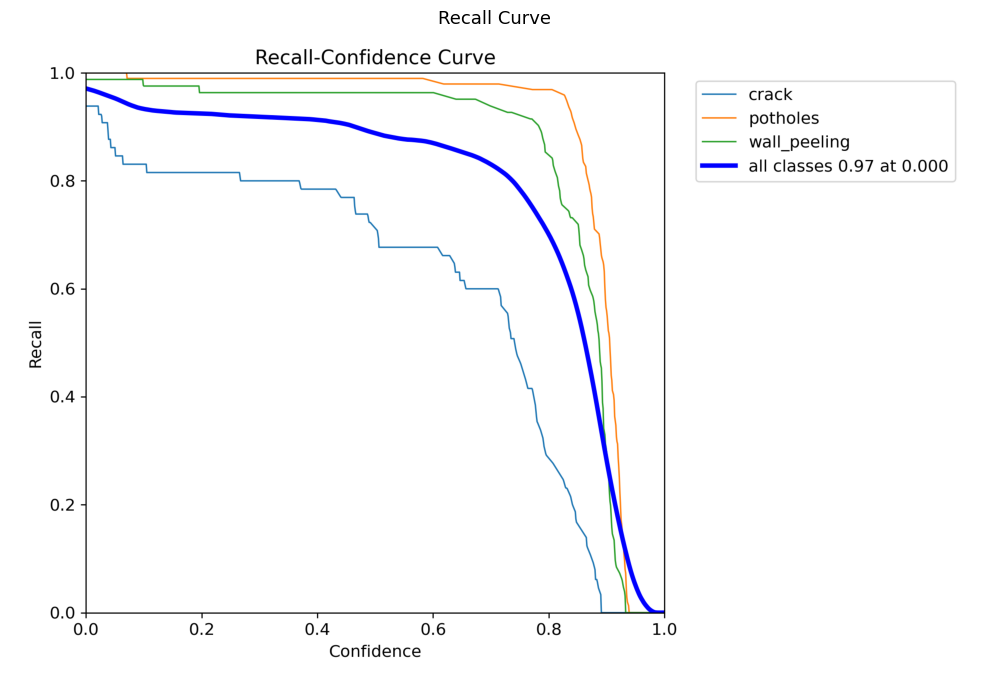

In [12]:
eval_plots = [
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('BoxPR_curve.png',                    'Precision-Recall Curve'),
    ('BoxP_curve.png',                     'Precision Curve'),
    ('BoxR_curve.png',                     'Recall Curve'),
]

run_dir = Path(PROJECT_DIR) / RUN

for filename, title in eval_plots:
    p = run_dir / filename
    if p.exists():
        plt.figure(figsize=(10, 7))
        plt.imshow(mpimg.imread(p))
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Not yet generated: {filename}")